In [8]:
import librosa
import sys
import os

sys.path.append('..')

from config import DATA_PATH

y, sr = librosa.load(DATA_PATH + '/train/DBA_9863_159.WAV', sr=None)
print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.4f} seconds")

Sample rate: 250000
Duration: 0.0416 seconds


In [2]:
# deleting C57 files 
c57_train = [
    os.path.join(train_dir, f)
    for f in os.listdir(train_dir)
    if f.startswith("C57") and f.endswith(".WAV")
]

c57_test = [
    os.path.join(test_dir, f)
    for f in os.listdir(test_dir)
    if f.startswith("C57") and f.endswith(".WAV")
]

for f in c57_train + c57_test:
    print("Deleting", f)
    os.remove(f)

print(f"Deleted {len(c57_train)} C57 train files")
print(f"Deleted {len(c57_test)} C57 test files")

Deleted 0 C57 train files
Deleted 0 C57 test files


In [7]:
train_dir = "../data/train"
test_dir = "../data/test"

# print number of files in each directory
print("num training files: " + str(len(os.listdir(train_dir))))
print("num test files: " + str(len(os.listdir(test_dir))))
print("total files: " + str(len(os.listdir(test_dir)) + len(os.listdir(train_dir))))


num training files: 20265
num test files: 2251
total files: 22516


In [5]:
# print info about a training file
training_data_1 = train_dir + "/DBA_3070_0.WAV"
audio, sr = librosa.load(training_data_1, sr=None)
print(audio.shape)
print(sr)

(6401,)
250000


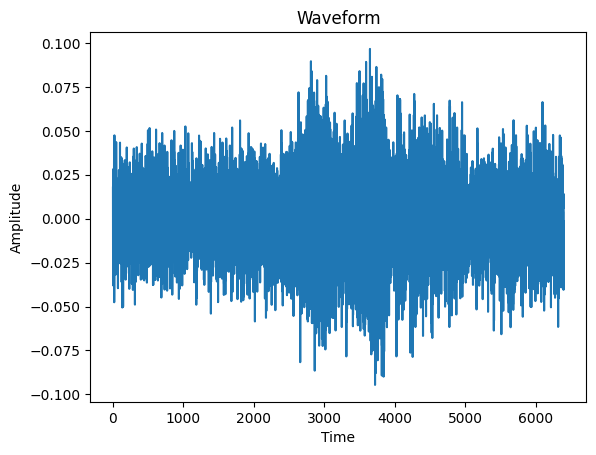

In [ ]:
# visualize waveforms
import librosa.display
import numpy as np
import matplotlib.pyplot as plt


plt.figure()
plt.plot(audio)
plt.title("Waveform") 
plt.xlabel("Time") # what are the units?
plt.ylabel("Amplitude") # what are the units?
plt.show()

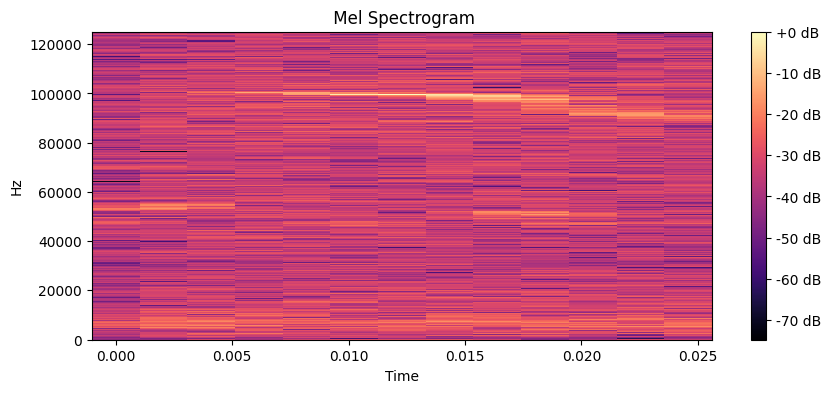

Shape: (6401,)
Sample rate: 250000
Duration: 0.025604 seconds


In [13]:
S = librosa.stft(audio)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title(' Mel Spectrogram')
plt.show()
print("Shape:", audio.shape)
print("Sample rate:", sr)
print("Duration:", len(audio)/sr, "seconds")

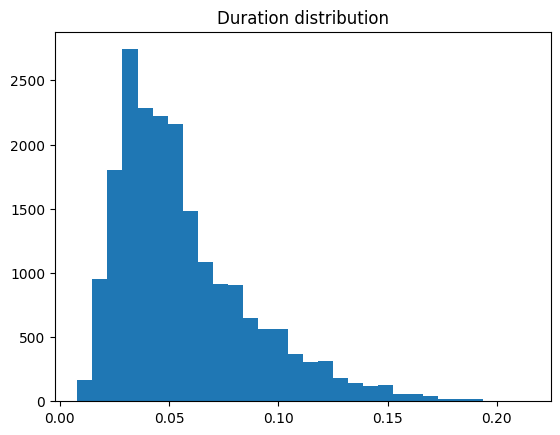

In [14]:
durations = []

for f in os.listdir(train_dir):
    audio, sr = librosa.load(os.path.join(train_dir, f), sr=None)
    durations.append(len(audio)/sr)
plt.hist(durations, bins=30)
plt.title("Duration distribution")
plt.show()